C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_19488\2827379630.py:52: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(), 256, [0, 256], color="black")
C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_19488\2827379630.py:63: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized_img.ravel(), 256, [0, 256], color="blue")
C:\Users\Dev Radia\AppData\Local\Temp\ipykernel_19488\2827379630.py:74: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(matched_img.ravel(), 256, [0, 256], color="green")


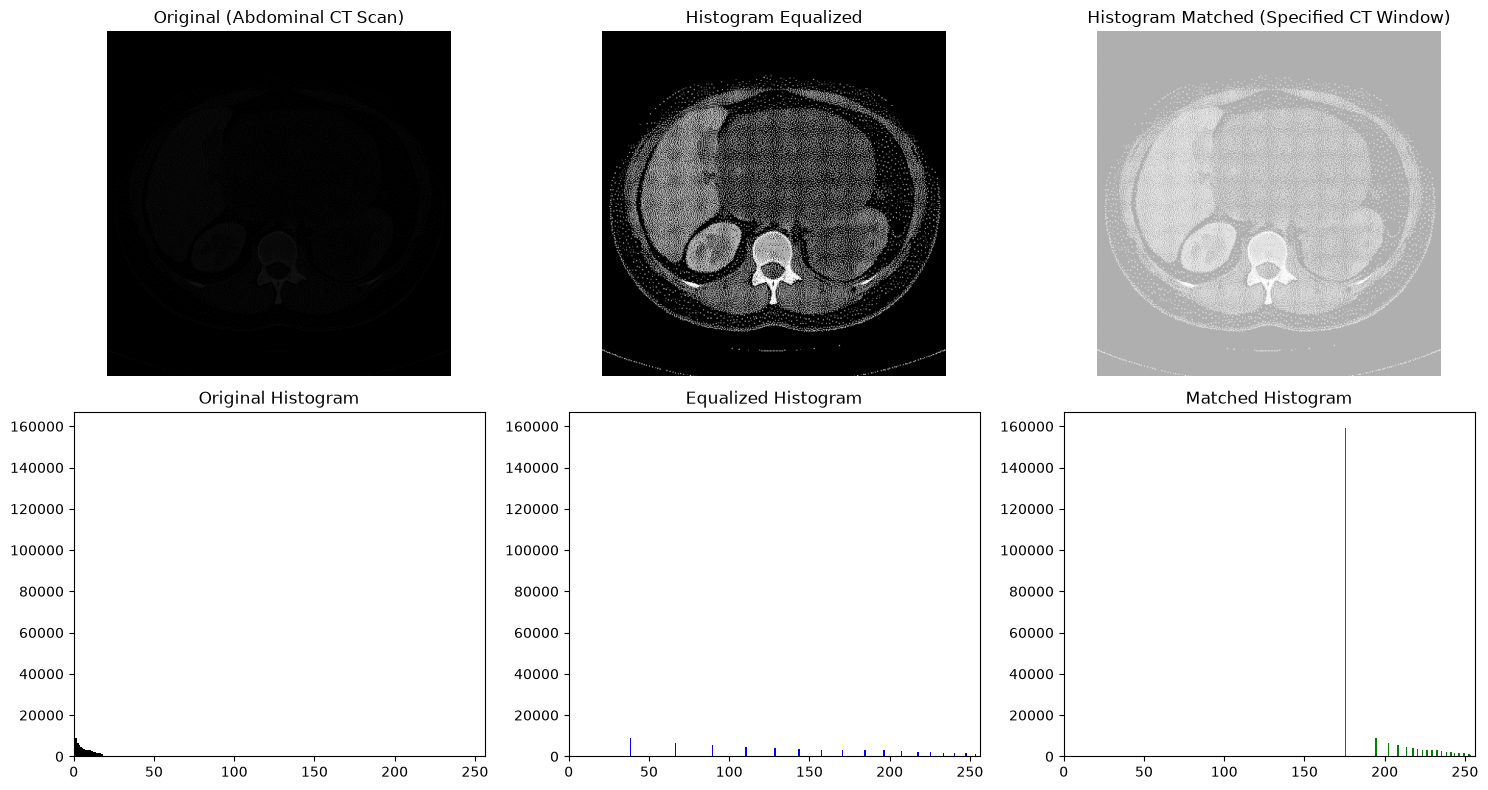

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

# 1. Load Image 5 (Abdominal CT Scan)
image_path = r"C:\Users\Dev Radia\Pictures\Screenshots\Screenshot 2026-09-22 081517.png"
raw_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if raw_image is None:
    print("Error: Image not found. Check the path!")
else:
    # Ensure single-channel 8-bit grayscale format
    if len(raw_image.shape) == 3 and raw_image.shape[2] == 4:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGRA2GRAY)
    elif len(raw_image.shape) == 3:
        image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)
    else:
        image = raw_image

    # 2. Global Histogram Equalization
    equalized_img = cv2.equalizeHist(image)

    # 3. Histogram Matching (Specification)
    # Define a target distribution that maintains diagnostic windowing:
    # keeps dark background at 0, smoothly stretches internal soft tissue mid-tones,
    # and reserves high intensities for dense bone.
    h, w = image.shape
    x = np.linspace(0, 255, 256)
    # Dual-peak model: peak for soft tissue (~80-120) and high-density bone (>200)
    target_pdf = np.exp(-0.5 * ((x - 90) / 35)**2) + 0.6 * np.exp(-0.5 * ((x - 220) / 25)**2)
    target_pdf[0] = target_pdf.max() * 2.0  # Preserve background zero density
    target_cdf = np.cumsum(target_pdf)
    target_cdf = target_cdf / target_cdf[-1]

    flat_pixels = np.interp(np.linspace(0, 1, h * w), target_cdf, np.arange(256))
    target_ref = flat_pixels.reshape((h, w)).astype(np.uint8)

    matched_img = match_histograms(image, target_ref)
    matched_img = np.clip(matched_img, 0, 255).astype(np.uint8)

    # 4. Display Processing Results and Histograms
    plt.figure(figsize=(15, 8))

    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title("Original (Abdominal CT Scan)")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.hist(image.ravel(), 256, [0, 256], color="black")
    plt.title("Original Histogram")
    plt.xlim([0, 256])

    # Equalized
    plt.subplot(2, 3, 2)
    plt.imshow(equalized_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Histogram Equalized")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.hist(equalized_img.ravel(), 256, [0, 256], color="blue")
    plt.title("Equalized Histogram")
    plt.xlim([0, 256])

    # Matched
    plt.subplot(2, 3, 3)
    plt.imshow(matched_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Histogram Matched (Specified CT Window)")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.hist(matched_img.ravel(), 256, [0, 256], color="green")
    plt.title("Matched Histogram")
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()